# IAU Project
**Andriy Kardash, Andrii Novitskiy**\
**Andriy Kardash - 51%**\
**Andrii Novitskiy - 49%**


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

### Faza 1

In [3]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
sns.set_theme(style="whitegrid")

RANDOM_STATE = 42

data_path = Path("Datasets/037")

files = [
    file
    for file in data_path.rglob("*")
    if file.is_file()
]

print("Number of files:", len(files))

for file in files:
    print(file)

gateways = pd.read_csv(data_path / "gateways.csv",sep=';')
readings = pd.read_csv(data_path / "readings.csv",sep='\t')
units = pd.read_csv(data_path / "units.csv",sep=',')

Number of files: 3
Datasets/037/units.csv
Datasets/037/gateways.csv
Datasets/037/readings.csv


# 1.1 Základný opis dát spolu s ich charakteristikami

### 1.1A Analýza štruktúr dát ako súbory (štruktúry a vzťahy, počet, typy, …), záznamy (štruktúry, počet záznamov, počet atribútov, typy, …)

### Počet záznamov a počet atribútov

In [4]:
print("Počet záznamov a počet atribútov v gateways", gateways.shape)
print("Počet záznamov a počet atribútov v readings", readings.shape)
print("Počet záznamov a počet atribútov v units", units.shape)

Počet záznamov a počet atribútov v gateways (16000, 14)
Počet záznamov a počet atribútov v readings (12618, 14)
Počet záznamov a počet atribútov v units (2000, 7)


### Typy v gateways

In [6]:
gateways.info()

<class 'pandas.DataFrame'>
RangeIndex: 16000 entries, 0 to 15999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   vendor           16000 non-null  str    
 1   gatewayId        16000 non-null  str    
 2   lat              16000 non-null  float64
 3   seen_last        16000 non-null  str    
 4   ipv4             16000 non-null  str    
 5   versionFirmware  16000 non-null  str    
 6   Technician       16000 non-null  str    
 7   id_unit          2000 non-null   float64
 8   modelHardware    16000 non-null  str    
 9   id_depot         16000 non-null  int64  
 10  macAddress       16000 non-null  str    
 11  Lon              16000 non-null  float64
 12  dbm_signal       16000 non-null  float64
 13  date_install     16000 non-null  str    
dtypes: float64(4), int64(1), str(9)
memory usage: 3.3 MB


### Typy v readings

In [5]:
readings.info()

<class 'pandas.DataFrame'>
RangeIndex: 12618 entries, 0 to 12617
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id_unit             12618 non-null  str    
 1   ts_cycle            12618 non-null  str    
 2   motorCurrent        12618 non-null  float64
 3   filter_dp           12087 non-null  float64
 4   oilTemperature      12618 non-null  float64
 5   pressure_reservoir  12618 non-null  float64
 6   pressure_working    12618 non-null  float64
 7   pressureOil         12618 non-null  float64
 8   vibrationRms        12130 non-null  float64
 9   flowmeter           12618 non-null  float64
 10  intake_humidity     11945 non-null  float64
 11  ambientNoise        12618 non-null  float64
 12  bearingTemp         12618 non-null  float64
 13  failure             12618 non-null  int64  
dtypes: float64(11), int64(1), str(2)
memory usage: 1.6 MB


### Typy v units

In [6]:
units.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Manufacturer  2000 non-null   str    
 1   class_duty    2000 non-null   str    
 2   id_unit       2000 non-null   int64  
 3   lastOverhaul  2000 non-null   str    
 4   lineCode      2000 non-null   str    
 5   id_depot      2000 non-null   int64  
 6   hoursService  1900 non-null   float64
dtypes: float64(1), int64(2), str(4)
memory usage: 173.2 KB


# Analyza GATEWAYS

In [7]:
gateways.head()

,vendor,gatewayId,lat,seen_last,ipv4,versionFirmware,Technician,id_unit,modelHardware,id_depot,macAddress,Lon,dbm_signal,date_install
0,"Holland, Moore and Foster",GW-00000,39.85515,25 Jan 2025,201.144.200.206,v3.4.1,Viviane Jopich,70.0,GWX-300,5,4b:57:9d:d8:85:7e,-8.87854,-67.0,2023-05-10
1,Castro Nascimento Lda.,GW-00001,39.97771,24 May 2024,162.167.208.12,v2.7.0,Klaus Peter Klemt-Klapp,463.0,GWX-200,67,28:1b:c1:bf:d2:72,-9.09701,-78.4,"04/18/2021, 00:00:00"
2,Green-Mitchell,GW-00002,39.68046,2024/10/21,214.16.189.57,v1.2.5,Steven Luna,759.0,NODE-9,109,2c:75:86:3d:87:96,-8.56949,-73.9,2021-10-22
3,Stey Fechner GbR,GW-00003,40.37614,09 Jul 2024,250.7.67.70,v3.4.1,Adriana Pinho,1966.0,GWX-100,31,50:33:0f:fe:aa:b6,-9.20827,-84.9,25 Apr 2021
4,Misicher Nette GmbH & Co. KGaA,GW-00004,40.07243,"10/24/2024, 00:00:00",225.244.98.178,v3.4.1,Mark Hines,457.0,NODE-7,34,01:f9:49:1a:95:c1,-6.35564,-71.6,2015/04/14


In [8]:
gateways.describe()

,lat,id_unit,id_depot,Lon,dbm_signal
count,16000.000000,2000.000000,16000.000000,16000.000000,16000.000000
mean,40.142132,1000.500000,59.246750,-7.753390,-69.955081
std,0.897981,577.494589,34.553675,0.889109,9.975559
min,38.600140,1.000000,0.000000,-9.299770,-108.700000
25%,39.363568,500.750000,29.000000,-8.521795,-76.700000
50%,40.144035,1000.500000,59.000000,-7.752610,-69.800000
75%,40.912925,1500.250000,89.000000,-6.987493,-63.200000
max,41.699970,2000.000000,119.000000,-6.200010,-40.000000


### seen_last a date_install
#### V stĺpcoch „seen_last“ a „date_install“ sa nachádzajú dátumy, avšak v súčasnosti sú uložené v rôznych formátoch a označené typom str\
#### Premeníme hodnoty v týchto stĺpcoch na typ date_time

In [4]:
gateways['seen_last'] = pd.to_datetime(gateways['seen_last'], format="mixed", errors="coerce")
gateways['date_install'] = pd.to_datetime(gateways['date_install'], format="mixed", errors="coerce")
gateways.head()

,vendor,gatewayId,lat,seen_last,ipv4,versionFirmware,Technician,id_unit,modelHardware,id_depot,macAddress,Lon,dbm_signal,date_install
0,"Holland, Moore and Foster",GW-00000,39.85515,2025-01-25,201.144.200.206,v3.4.1,Viviane Jopich,70.0,GWX-300,5,4b:57:9d:d8:85:7e,-8.87854,-67.0,2023-05-10
1,Castro Nascimento Lda.,GW-00001,39.97771,2024-05-24,162.167.208.12,v2.7.0,Klaus Peter Klemt-Klapp,463.0,GWX-200,67,28:1b:c1:bf:d2:72,-9.09701,-78.4,2021-04-18
2,Green-Mitchell,GW-00002,39.68046,2024-10-21,214.16.189.57,v1.2.5,Steven Luna,759.0,NODE-9,109,2c:75:86:3d:87:96,-8.56949,-73.9,2021-10-22
3,Stey Fechner GbR,GW-00003,40.37614,2024-07-09,250.7.67.70,v3.4.1,Adriana Pinho,1966.0,GWX-100,31,50:33:0f:fe:aa:b6,-9.20827,-84.9,2021-04-25
4,Misicher Nette GmbH & Co. KGaA,GW-00004,40.07243,2024-10-24,225.244.98.178,v3.4.1,Mark Hines,457.0,NODE-7,34,01:f9:49:1a:95:c1,-6.35564,-71.6,2015-04-14


#### Údaje súvisiace s dátumom sú teraz uložené vo formáte datetime. Teraz skontrolujeme, či je možná situácia, v ktorej je hodnota seen_last menšia ako date_install.

In [8]:
possibly_wrong_datetime = gateways[gateways["seen_last"] < gateways["date_install"]]
print(possibly_wrong_datetime.shape)
possibly_wrong_datetime.head()

(736, 14)


,vendor,gatewayId,lat,seen_last,ipv4,versionFirmware,Technician,id_unit,modelHardware,id_depot,macAddress,Lon,dbm_signal,date_install
69,Hamann GmbH & Co. KGaA,GW-00069,39.58994,2024-04-22,203.176.96.0,v3.4.1,Olena Höfig,1981.0,GWX-300,4,da:a9:24:d4:d2:84,-6.51028,-74.7,2024-10-16
129,Tran-Lewis,GW-00129,39.76848,2024-07-04,112.2.71.65,v3.4.1,Erica Harris,1550.0,GWX-100,33,f9:af:69:ba:c1:43,-7.82595,-69.1,2024-11-24
145,Striebitz AG,GW-00145,40.12228,2024-06-27,164.54.253.102,v2.7.0,Traugott Bähr,750.0,GWX-300,65,ab:ab:ab:9f:38:69,-9.05759,-75.7,2024-10-28
164,Maia,GW-00164,41.28766,2024-08-08,73.180.151.246,v3.4.1,Hans-Eberhard Wende,943.0,GWX-300,14,a5:24:96:3d:3a:71,-8.74448,-73.6,2024-09-09
173,"Holland, Moore and Foster",GW-00173,40.30317,2024-02-03,130.208.176.32,v3.4.1,Amanda Mcneil,1130.0,GWX-300,40,e3:46:1b:06:fa:f1,-6.53016,-71.0,2024-04-19


#### V našom prípade je 736 riadkov, v ktorých údaje nemajú logickú súvislosť, avšak je potrebné sa opýtať vyučujúceho

##### Skontrolujeme počet riadkov s nulami a počet duplicitných riadkov; vylúčime macadress, ipv4 a id_units, pretože sú vždy jedinečné

In [5]:
gateways.isna().sum()

vendor                 0
gatewayId              0
lat                    0
seen_last              0
ipv4                   0
versionFirmware        0
Technician             0
id_unit            14000
modelHardware          0
id_depot               0
macAddress             0
Lon                    0
dbm_signal             0
date_install           0
dtype: int64

In [6]:
gateways.isnull().sum()

vendor                 0
gatewayId              0
lat                    0
seen_last              0
ipv4                   0
versionFirmware        0
Technician             0
id_unit            14000
modelHardware          0
id_depot               0
macAddress             0
Lon                    0
dbm_signal             0
date_install           0
dtype: int64

#### Stĺpec id_units obsahuje celkom 2000 nenulových prvkov, všetky ostatné riadky sú úplne vyplnené

In [16]:
gateways.drop(columns =['ipv4', 'macAddress', 'id_unit']).duplicated().sum()

np.int64(0)

###### Neexistuje žiadna duplikácia

In [7]:
gateways.nunique()

vendor                40
gatewayId          16000
lat                15597
seen_last            400
ipv4               16000
versionFirmware        3
Technician           120
id_unit             2000
modelHardware          5
id_depot             120
macAddress         16000
Lon                15591
dbm_signal           601
date_install        3611
dtype: int64

#### V stĺpcoch „versionFirmware“ a „modelHardware“ je málo jedinečných prvkov, z čoho usudzujeme, že ide o kategorické údaje

<Axes: xlabel='versionFirmware', ylabel='Count'>

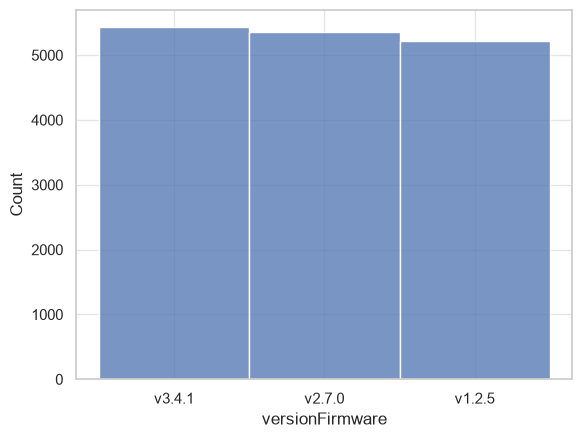

In [8]:
sns.histplot(gateways["versionFirmware"])

<Axes: xlabel='modelHardware', ylabel='Count'>

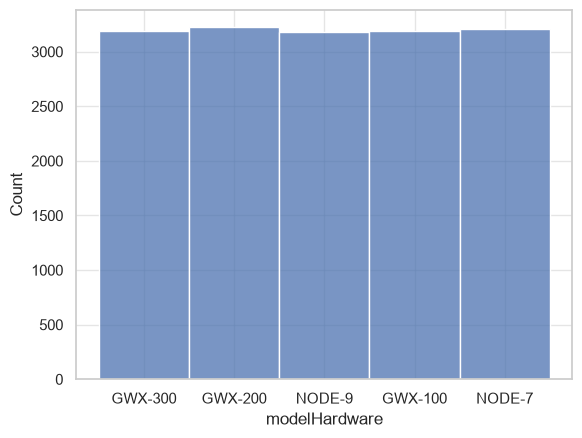

In [9]:
sns.histplot(gateways["modelHardware"])

##### Údaje sú rozdelené medzi jednotlivé typy takmer rovnomerne

### Pozrime sa na rozdelenie všetkých číselných údajov v GATEWAYS

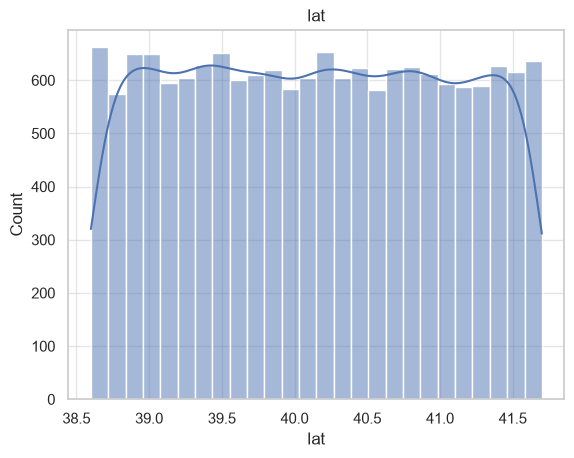

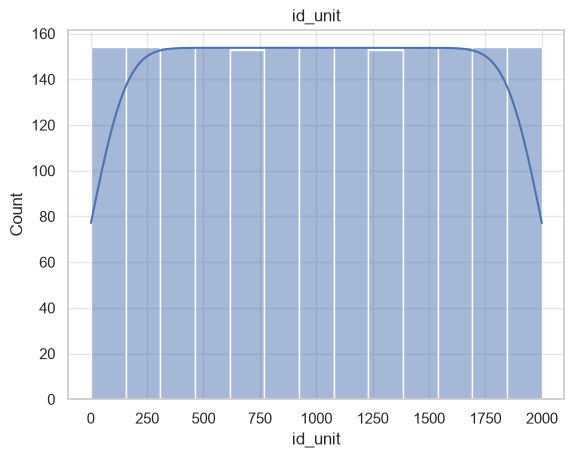

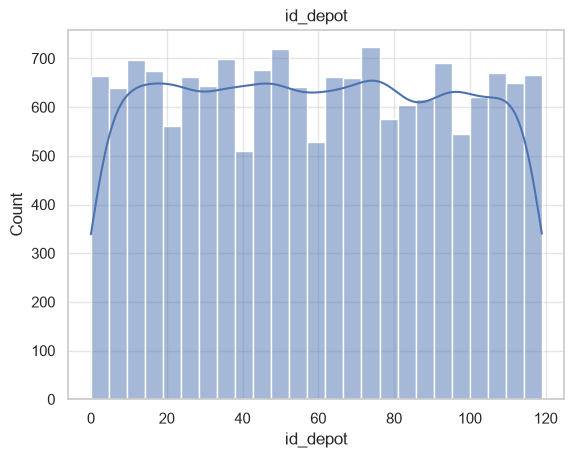

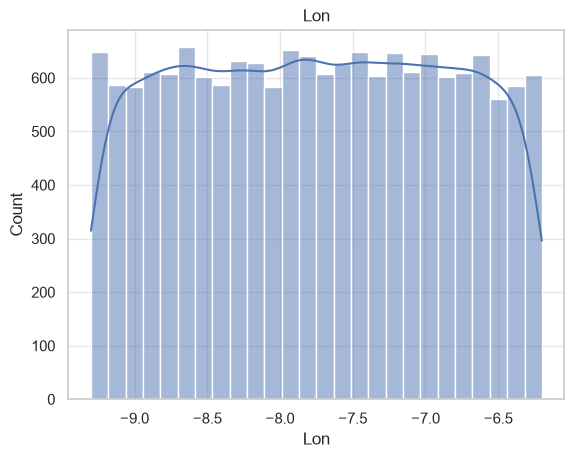

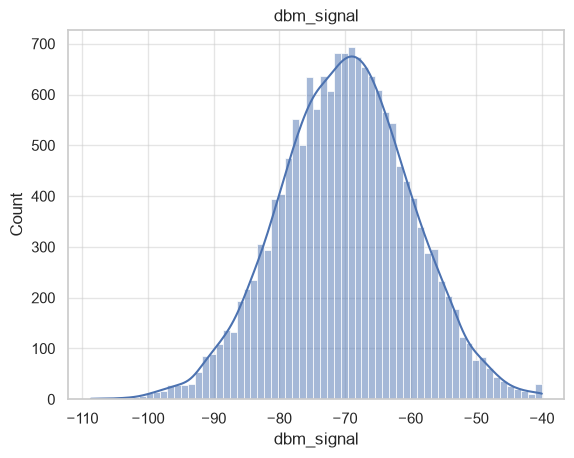

In [18]:
sns.set_theme(style="whitegrid")

for col in gateways.select_dtypes("number"):
    sns.histplot(gateways[col], kde=True)
    plt.title(col)
    plt.show()

In [21]:
(gateways['dbm_signal'] > -40).sum()

np.int64(0)

#### Lon, lat, id_depot sú rovnomerne rozložené, na prvý pohľad aj dbm_signal, avšak ak si všimneme počet hodnôt v bode -40, začínajú sa vynárať otázky. Podľa vzorca (-40-(-69,9))/9,9 ≈ 3,0σ v normálnom rozdelení sa za hranicou +3σ nachádza ≈ 0,134 % hodnôt: 16 000 * 0,00134 ≈ 21. Malo by byť ≈ 21 hodnôt väčších ako −40. V skutočnosti je ich 0, a presne na hodnote −40 je 21.

Text(0.5, 1.0, 'Horný okraj: vrchol na −40')

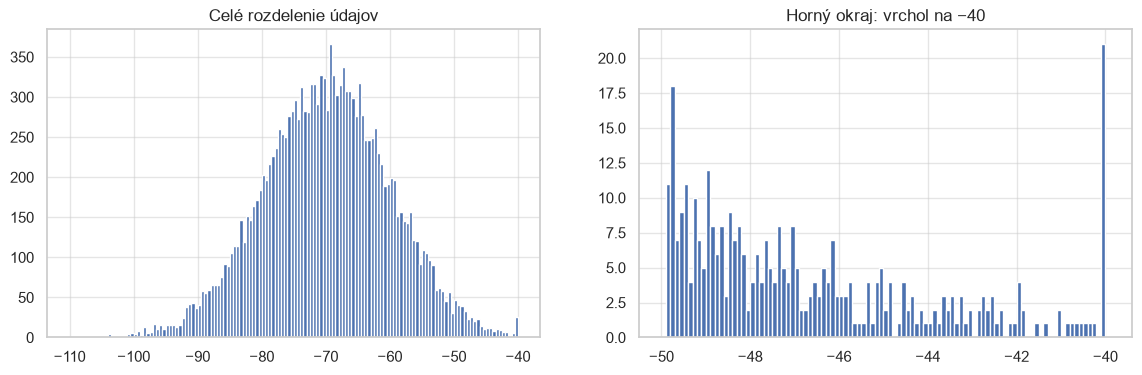

In [20]:
s = gateways["dbm_signal"]
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].hist(s, bins=np.arange(-110, -39.9, 0.5))
ax[0].set_title("Сelé rozdelenie údajov")
ax[1].hist(s[s > -50], bins=np.arange(-50, -39.9, 0.1))
ax[1].set_title("Horný okraj: vrchol na −40")

In [13]:
num = gateways.select_dtypes("number").drop(columns=["id_unit", "id_depot"])
corr = num.corr(method="spearman")
print(corr)

                 lat       Lon  dbm_signal
lat         1.000000  0.001840    0.000723
Lon         0.001840  1.000000    0.005073
dbm_signal  0.000723  0.005073    1.000000


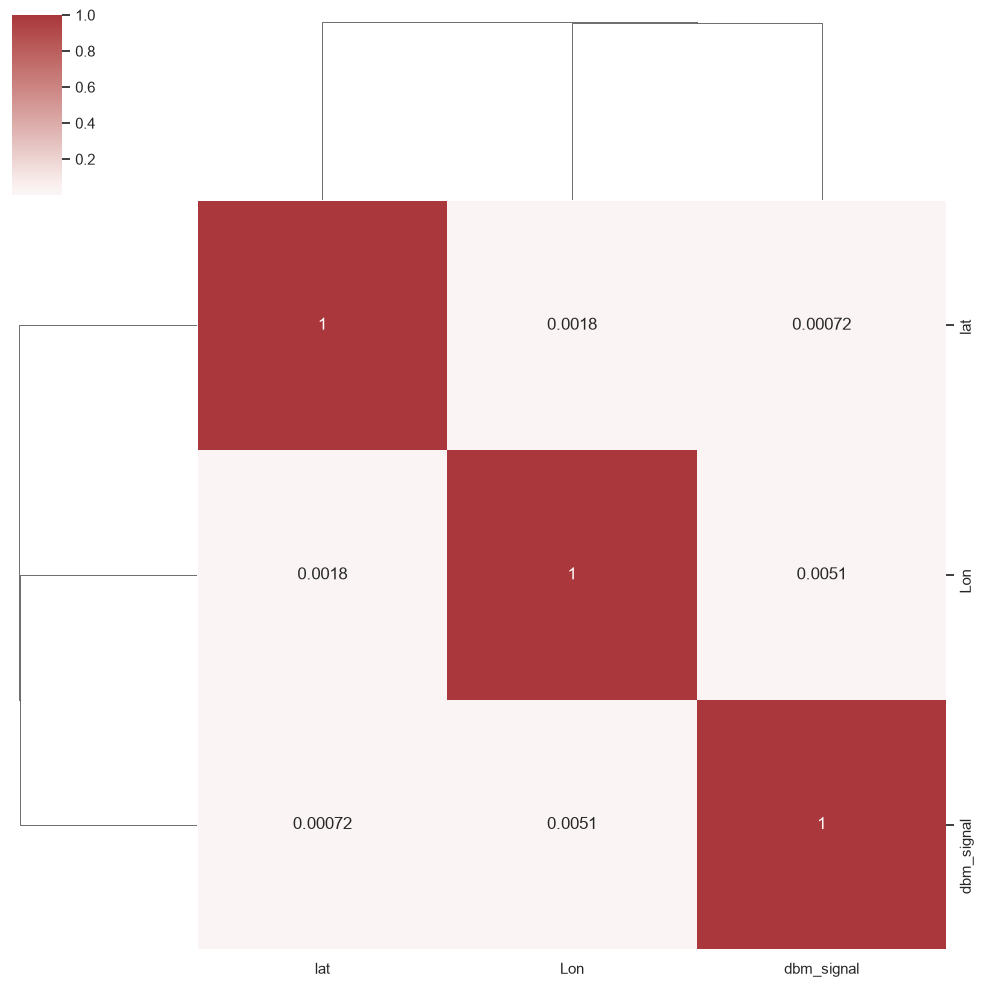

In [14]:
sns.clustermap(corr, cmap="vlag", center = 0, annot = len(corr) < 15)

In [15]:
pairs = (corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
             .stack().dropna()
             .sort_values(key=abs, ascending=False))

In [16]:
print(pairs)

Lon  dbm_signal    0.005073
lat  Lon           0.001840
     dbm_signal    0.000723
dtype: float64


In [17]:
gateways[["Lon", "lat", "dbm_signal"]].describe()

,Lon,lat,dbm_signal
count,16000.000000,16000.000000,16000.000000
mean,-7.753390,40.142132,-69.955081
std,0.889109,0.897981,9.975559
min,-9.299770,38.600140,-108.700000
25%,-8.521795,39.363568,-76.700000
50%,-7.752610,40.144035,-69.800000
75%,-6.987493,40.912925,-63.200000
max,-6.200010,41.699970,-40.000000


<Axes: xlabel='Lon', ylabel='lat'>

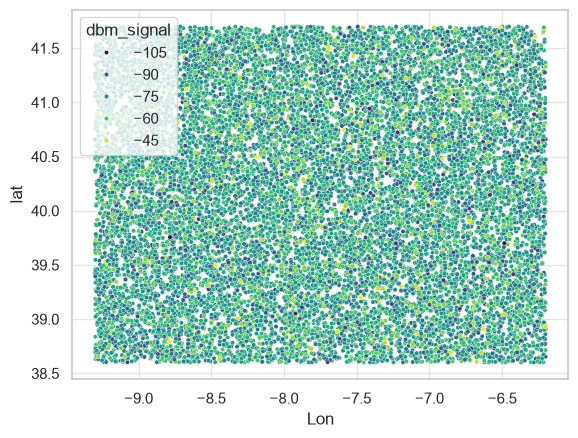

In [19]:
sns.scatterplot(data=gateways, x="Lon", y="lat", hue="dbm_signal", s=10, palette="viridis")

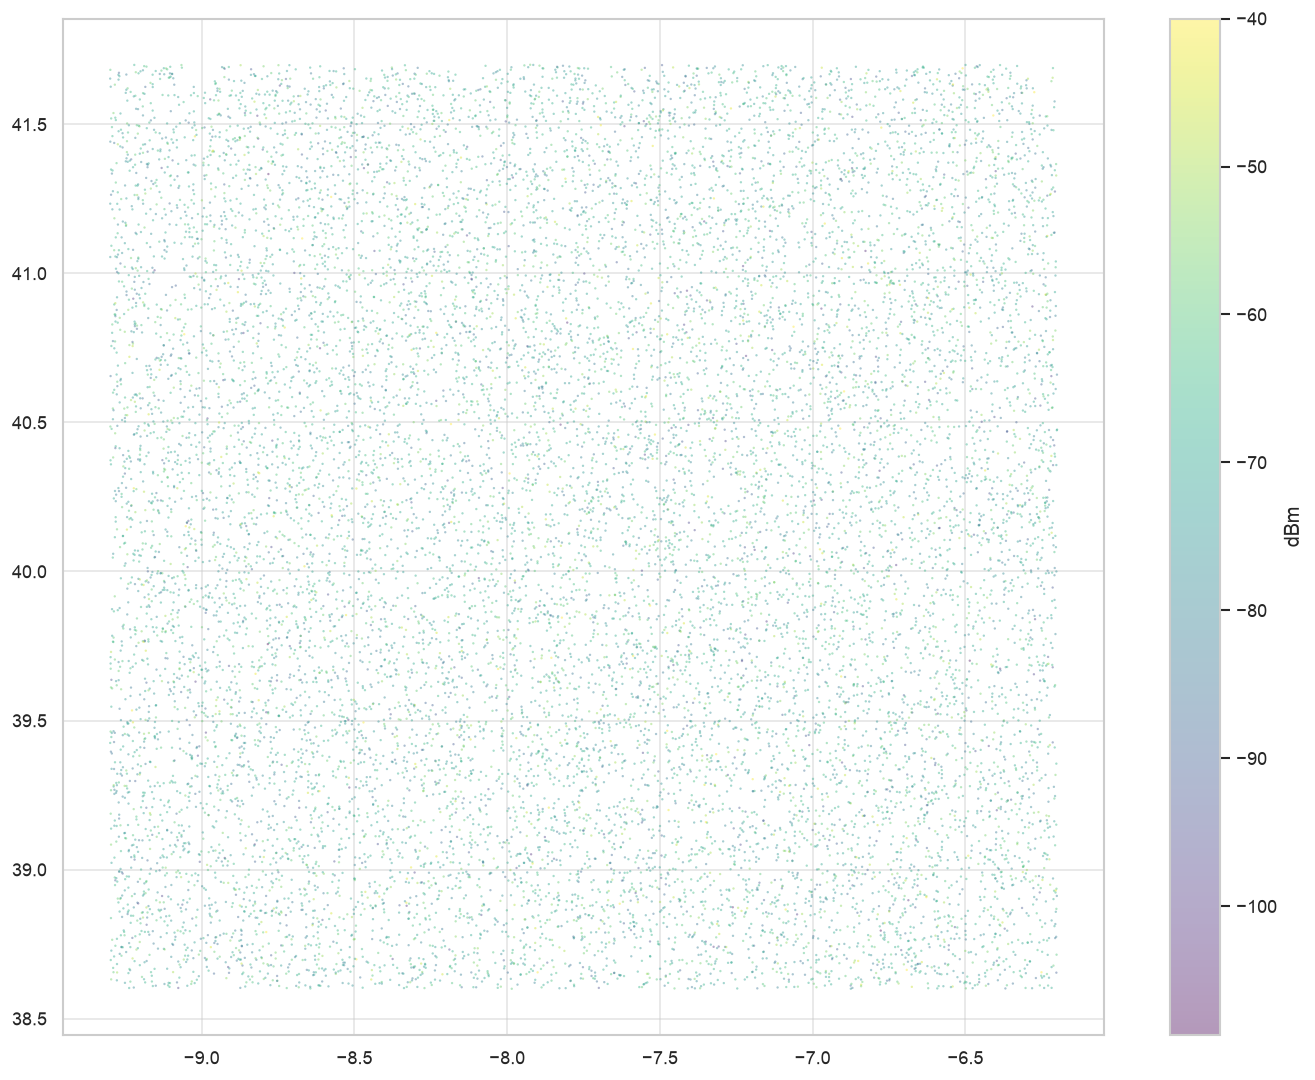

In [21]:
fig, ax = plt.subplots(figsize=(14, 11), dpi=120)
sc = ax.scatter(gateways["Lon"], gateways["lat"], c=gateways["dbm_signal"],
                s=2, alpha=0.4, linewidths=0, cmap="viridis")
fig.colorbar(sc, label="dBm")

-----------------------------Reading Part-----------------------------------------

In [7]:
readings.head(10)

,id_unit,ts_cycle,motorCurrent,filter_dp,oilTemperature,pressure_reservoir,pressure_working,pressureOil,vibrationRms,flowmeter,intake_humidity,ambientNoise,bearingTemp,failure
0,U01130,"02/10/2023, 17:12:00",4.36969,28.64924,49.67845,7.34282,7.31041,2.31187,4.99789,30.25891,66.67165,72.94257,64.95347,0
1,U00848,18 Sep 2023,4.22091,23.03530,41.77282,8.50849,8.53387,3.60240,1.87873,30.49048,89.24165,85.55312,74.46724,0
2,U00943,2023/12/29,2.80830,44.64527,69.78227,9.84619,9.70007,4.82881,4.49602,31.08300,80.81591,74.80889,60.05191,0
3,U01894,"11/12/2023, 15:24:00",4.45080,23.51547,47.49275,10.08831,10.00805,4.95817,2.15054,24.19140,17.74420,78.35942,67.82175,0
4,U00083,18 Nov 2023,3.97643,17.19827,70.25846,7.86674,7.88600,2.37735,4.11747,26.91899,19.60671,66.19757,59.54418,0
5,U00777,2023-07-06,3.22686,28.24065,60.57740,9.00718,9.20808,4.48304,3.30593,32.48052,19.83272,83.38358,65.77489,0
6,U00688,09 Sep 2023,2.76081,15.84201,60.89518,9.15108,9.37328,3.61046,2.11979,25.28018,91.39651,71.09905,62.27600,0
7,U01370,2023/09/20,4.50663,19.46103,42.76148,8.03207,8.31141,3.43468,1.54556,21.92854,44.11174,70.03922,60.35054,0
8,U00247,2023/09/25,4.64585,41.59096,71.94085,8.59036,8.89304,3.66107,1.82557,30.47198,65.18442,67.32028,69.19294,0
9,U00946,2023-12-14,9.18168,37.39852,52.08046,8.02453,8.24464,2.78188,5.34202,33.58937,31.92825,68.35946,62.49142,0


In [8]:
readings.describe()

,motorCurrent,filter_dp,oilTemperature,pressure_reservoir,pressure_working,pressureOil,vibrationRms,flowmeter,intake_humidity,ambientNoise,bearingTemp,failure
count,12618.000000,12087.000000,12618.000000,12618.000000,12618.000000,12618.000000,12130.000000,12618.000000,11945.000000,12618.000000,12618.000000,12618.000000
mean,5.340779,24.040491,52.184604,8.687973,8.686789,3.691886,3.072051,27.986990,52.747386,75.024082,65.024672,0.121335
std,3.429454,11.217930,56.713320,0.604042,0.623115,0.563594,1.624156,4.053328,24.456748,6.017768,7.997717,0.326529
min,0.000000,7.506110,-999.000000,6.500000,6.347720,1.554030,0.500000,15.000000,10.001260,55.000000,33.136820,0.000000
25%,3.762555,16.337870,47.082152,8.287690,8.272227,3.312710,1.936753,25.249323,31.525010,70.909368,59.645525,0.000000
50%,5.174205,21.434190,55.186290,8.685490,8.683635,3.689295,2.711645,28.005920,52.733700,75.075945,64.941755,0.000000
75%,6.717493,28.699815,63.292127,9.088342,9.109485,4.068568,3.807655,30.724918,74.001870,79.058482,70.435177,0.000000
max,99.000000,120.000000,95.000000,10.500000,10.500000,5.734440,14.000000,40.000000,94.999800,95.000000,94.028610,1.000000


In [9]:
readings.info()

<class 'pandas.DataFrame'>
RangeIndex: 12618 entries, 0 to 12617
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id_unit             12618 non-null  str    
 1   ts_cycle            12618 non-null  str    
 2   motorCurrent        12618 non-null  float64
 3   filter_dp           12087 non-null  float64
 4   oilTemperature      12618 non-null  float64
 5   pressure_reservoir  12618 non-null  float64
 6   pressure_working    12618 non-null  float64
 7   pressureOil         12618 non-null  float64
 8   vibrationRms        12130 non-null  float64
 9   flowmeter           12618 non-null  float64
 10  intake_humidity     11945 non-null  float64
 11  ambientNoise        12618 non-null  float64
 12  bearingTemp         12618 non-null  float64
 13  failure             12618 non-null  int64  
dtypes: float64(11), int64(1), str(2)
memory usage: 1.6 MB


In [10]:
readings.nunique()

id_unit                2109
ts_cycle               4203
motorCurrent          12306
filter_dp             11893
oilTemperature        12371
pressure_reservoir    12048
pressure_working      12055
pressureOil           12043
vibrationRms          11786
flowmeter             12348
intake_humidity       11754
ambientNoise          12382
bearingTemp           12405
failure                   2
dtype: int64

In [11]:
readings['ts_cycle'] = pd.to_datetime(readings['ts_cycle'], format="mixed", errors="coerce")
readings.head()

,id_unit,ts_cycle,motorCurrent,filter_dp,oilTemperature,pressure_reservoir,pressure_working,pressureOil,vibrationRms,flowmeter,intake_humidity,ambientNoise,bearingTemp,failure
0,U01130,2023-02-10 17:12:00,4.36969,28.64924,49.67845,7.34282,7.31041,2.31187,4.99789,30.25891,66.67165,72.94257,64.95347,0
1,U00848,2023-09-18 00:00:00,4.22091,23.03530,41.77282,8.50849,8.53387,3.60240,1.87873,30.49048,89.24165,85.55312,74.46724,0
2,U00943,2023-12-29 00:00:00,2.80830,44.64527,69.78227,9.84619,9.70007,4.82881,4.49602,31.08300,80.81591,74.80889,60.05191,0
3,U01894,2023-11-12 15:24:00,4.45080,23.51547,47.49275,10.08831,10.00805,4.95817,2.15054,24.19140,17.74420,78.35942,67.82175,0
4,U00083,2023-11-18 00:00:00,3.97643,17.19827,70.25846,7.86674,7.88600,2.37735,4.11747,26.91899,19.60671,66.19757,59.54418,0


In [12]:
readings.nunique()

id_unit                2109
ts_cycle               3471
motorCurrent          12306
filter_dp             11893
oilTemperature        12371
pressure_reservoir    12048
pressure_working      12055
pressureOil           12043
vibrationRms          11786
flowmeter             12348
intake_humidity       11754
ambientNoise          12382
bearingTemp           12405
failure                   2
dtype: int64

In [20]:
wrong_temp = readings[readings["oilTemperature"] < -150]
wrong_temp.head()

,id_unit,ts_cycle,motorCurrent,filter_dp,oilTemperature,pressure_reservoir,pressure_working,pressureOil,vibrationRms,flowmeter,intake_humidity,ambientNoise,bearingTemp,failure
228,U00965,2023-05-24,2.84660,59.32372,-999.0,8.03468,7.98402,3.09557,2.63337,30.14723,50.05890,68.59031,76.00988,1
250,U01372,2023-03-18,3.20819,14.91370,-999.0,8.38727,8.32364,2.94058,4.26056,34.31242,43.56705,84.69735,62.97185,0
501,U00316,2023-04-02,2.95373,11.27180,-999.0,9.40675,9.19778,4.35589,2.64198,29.94388,18.85306,73.82276,70.80111,0
757,U01163,2023-05-08,1.93646,15.80406,-999.0,8.31141,8.29735,3.16373,2.85847,31.34508,35.33513,75.56880,65.06621,0
887,U00321,2023-11-23,5.77294,13.13680,-999.0,9.09795,9.12452,4.05044,1.88460,27.43565,16.81501,63.74405,56.79891,0


In [17]:
wrong_temp.shape

(35, 14)

In [18]:
wrong_temp.tail()

,id_unit,ts_cycle,motorCurrent,filter_dp,oilTemperature,pressure_reservoir,pressure_working,pressureOil,vibrationRms,flowmeter,intake_humidity,ambientNoise,bearingTemp,failure
10705,U01235,2023-12-13 01:07:00,8.34516,20.60030,-999.0,8.32820,8.36516,3.88248,1.79373,34.05536,80.58041,68.44674,70.90025,0
11541,U01743,2023-04-30 00:00:00,5.21793,19.85782,-999.0,8.21757,8.01408,3.53147,2.48807,32.18600,29.77964,79.54890,63.12499,0
11859,U00104,2023-02-19 09:29:00,5.86511,26.68680,-999.0,9.21750,9.35922,4.31252,2.38092,31.49388,76.87856,85.38941,64.54108,0
12173,U00674,2023-11-27 00:00:00,7.67194,13.53450,-999.0,8.49151,8.59377,3.78047,4.60655,26.72838,65.14463,74.79178,71.08119,1
12612,U01173,2023-12-19 09:52:00,3.56056,34.60445,-999.0,8.38977,8.50667,3.82097,4.01014,23.27665,46.42377,81.64983,70.28943,1


In [21]:
conflict = readings['oilTemperature'] < -150
print(conflict.sum())

35


In [25]:
readings.loc[conflict, 'oilTemperature'] = np.nan
readings.describe()

,ts_cycle,motorCurrent,filter_dp,oilTemperature,pressure_reservoir,pressure_working,pressureOil,vibrationRms,flowmeter,intake_humidity,ambientNoise,bearingTemp,failure
count,12618,12618.000000,12087.000000,12583.000000,12618.000000,12618.000000,12618.000000,12130.000000,12618.000000,11945.000000,12618.000000,12618.000000,12618.000000
mean,2023-07-04 22:19:16.019971,5.340779,24.040491,55.108507,8.687973,8.686789,3.691886,3.072051,27.986990,52.747386,75.024082,65.024672,0.121335
min,2023-01-01 00:00:00,0.000000,7.506110,15.000000,6.500000,6.347720,1.554030,0.500000,15.000000,10.001260,55.000000,33.136820,0.000000
25%,2023-04-05 19:44:45,3.762555,16.337870,47.175610,8.287690,8.272227,3.312710,1.936753,25.249323,31.525010,70.909368,59.645525,0.000000
50%,2023-07-06 00:00:00,5.174205,21.434190,55.232450,8.685490,8.683635,3.689295,2.711645,28.005920,52.733700,75.075945,64.941755,0.000000
75%,2023-10-05 00:00:00,6.717493,28.699815,63.307110,9.088342,9.109485,4.068568,3.807655,30.724918,74.001870,79.058482,70.435177,0.000000
max,2023-12-31 20:42:00,99.000000,120.000000,95.000000,10.500000,10.500000,5.734440,14.000000,40.000000,94.999800,95.000000,94.028610,1.000000
std,NaN,3.429454,11.217930,11.957960,0.604042,0.623115,0.563594,1.624156,4.053328,24.456748,6.017768,7.997717,0.326529


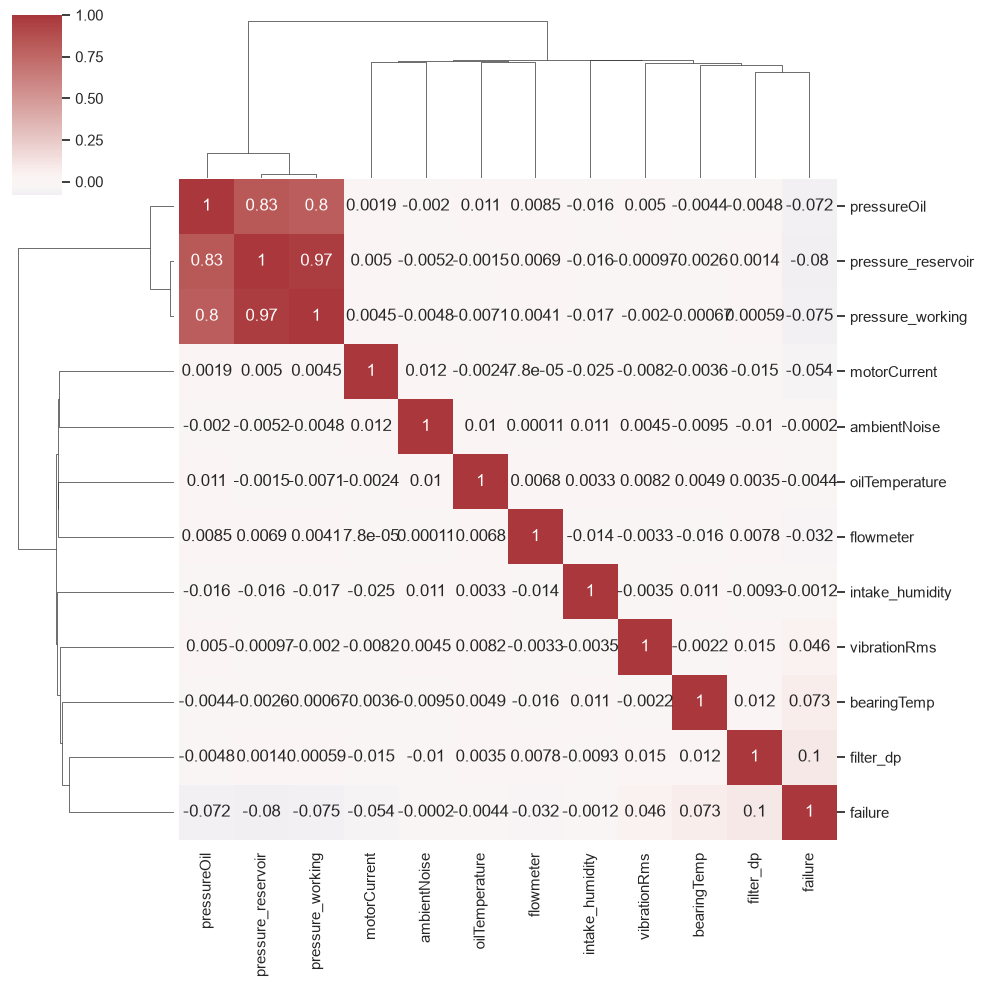

In [35]:
readings.corr(numeric_only=True)
num = readings.select_dtypes("number")
corr = num.corr(method="spearman")
sns.clustermap(corr, cmap="vlag", center = 0, annot = len(corr) < 15)
